# Red GAN (Generativa Antagónica/Adversarial).    

Una **red adversarial generativa**, o **GAN**, es un modelo de machine learning diseñado para generar datos realistas mediante el aprendizaje de patrones a partir de conjuntos de datos de entrenamiento existentes.    

Opera dentro de un marco de ***aprendizaje no supervisado*** mediante el uso de técnicas de deep learning, donde dos redes neuronales trabajan en oposición: *una genera datos*, mientras que *la otra evalúa si los datos son reales o generados*.

Las **Redes Generativas Adversariales (GANs)** son una clase de modelos de aprendizaje profundo compuesto por dos redes neuronales, una red generativa y una discriminativa, que se entrenan en un proceso de competencia:

- El ***generador*** es responsable de crear nuevos datos que se parezcan lo máximo posible al conjunto de datos original.
- El ***discriminador***, por su parte, tiene como objetivo distinguir entre los datos generados por el generador y los reales del conjunto original.       


<img src="./img/esquemaGAN.jpg">

Esta competición entre el generador y el discriminador empuja a ambas redes a mejorar. Es decir, el generador aprenderá a producir datos más realistas y el discriminador mejorará en la distinción entre datos reales y falsos.

Las GANs han abierto un abanico de posibilidades en distintos campos, desde la generación de imágenes hasta la mejora de la resolución de fotografías o incluso el aumento del conjunto de datos de entrenamiento para un modelo de aprendizaje automático.

## Propuesta práctica: Generación de rostros humanos con Redes Adversariales   

### Introducción   

Para llevar a cabo el entrenamiento y las pruebas iniciales de esta GAN se utiliza el dataset [CIFAR10 (Canadian Institute For Advanced Research)](https://www.cs.toronto.edu/~kriz/cifar.html), que es una colección de imágenes utilizadas ampliamente para algoritmos de aprendizaje automático y visión artificial. Fue desarrollado por investigadores del instituto CIFAR y consta de 60,000 imágenes a color de 32x32 en 10 clases diferentes.

Se propone al alumno que, una vez probada la GAN, pase a implementar la generación de rostros humanos haciendo uso del dataset [CelebA](https://www.kaggle.com/datasets/jessicali9530/celeba-dataset/data).
El dataset CelebA (CelebFaces Attributes Dataset) es un conjunto de 202.599 imágenes de rostros humanos extraídas de celebridades, que incluye aproximadamente 10.000 rostros diferentes.    

Estas imágenes están centradas y alineadas, lo que facilita su uso en tareas de visión por computador donde se requiere consistencia estructural en las entradas. Este es un ejemplo de rostros que aparecen en el dataset:

<img src="./img/setentrenamiento.png">

## Desarrollo de la red GAN   

La red GAN que se implementa a continuación es una DCGAN para poder crear rostros humanos a partir del dataset CelebA que se puede encontrar en Kaggle y para su entrenamiento inicial, tal y como se ha comentado, se utiliza el dataset CIFAR10. Como se propone al final de este notebook, corre por cuenta del alumno realizar la adaptación al dataset CelebA.

### Arquitectura del generador

La arquitectura del generador está compuesta por 5 capas convolucionales y 1 densa inicial que convierte el vector de ruido a una una representación de 4x4x128 usando la activación LeakyReLU.    

Después hay 4 capas de upsampling para poder producir imágenes de 64×64 con tres canales de color RGB.    

El Batch Normalization es una técnica que se utiliza para mejorar la estabilidad y el rendimiento durante el entrenamiento normalizando las activaciones de las capas de la red.   

### Arquitectura del discriminador     

El discriminador se compone de 4 capas de convolución 2D con activaciones LeakyReLU para mejorar la propagación del gradiente e intercalando capas de Dropout para reducir el sobreajuste.    
Finalmente el discriminador aplana las características y a través de una capa densa con activación sigmoide saca una variable binaria para indicar si la entrada es real o falsa.    

### Optimización   

Se han establecido los optimizadores Adam para la red GAN, pues permiten ajustar las tasas de aprendizaje de manera individual para cada parámetro, ayudando a mejorar la convergencia y permitiendo escapar al modelo de los mínimos locales.   

### Entrenamiento   

Se ha implementado una función de entrenamiento compuesta por un ciclo de entrenamiento dividido en 2 fases:   
- Durante la fase 1, el discriminador se actualiza usando un lote de imágenes mezcladas.
- En la fase 2, el generador se entrena para generar imágenes “reales” que engañen al discriminador.



## Proceso de implementación de la GAN   

### 1. Importamos librerías necesarias

In [1]:

import tensorflow as tf
import tensorflow.keras as keras

import numpy as np
import matplotlib.pyplot as plt
from IPython import display

from keras.utils import plot_model

print (tf.__version__)

2026-03-03 15:26:31.480457: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-03 15:26:31.580292: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-03 15:26:34.323386: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


2.20.0


### 2. Preparamos e implementamos funciones y utilidades

In [2]:
# Funcion para visualizar los resultados de las imágenes generadas por el modelo

def plot_results(images, n_cols=None, unnorm=True):
    '''visualizes fake images'''
    display.clear_output(wait=False)  

    n_cols = n_cols or len(images)
    n_rows = (len(images) - 1) // n_cols + 1
    

    if images.shape[-1] == 1:
        images = np.squeeze(images, axis=-1)

    plt.figure(figsize=(n_cols, n_rows))
    
    for index, image in enumerate(images):
        plt.subplot(n_rows, n_cols, index + 1)
        imageorg = image
        if unnorm:
          imageorg = (image +1) * 0.5
        plt.imshow(imageorg)
        plt.axis("off")

### 3. Descarga, análisis y adecuación de la información del dataset de entrenamiento **CIFAR10**

In [3]:
# Descargamos el dataset de CIFAR-10 para entrenar el modelo.
(X_train, _), _ = keras.datasets.cifar10.load_data()

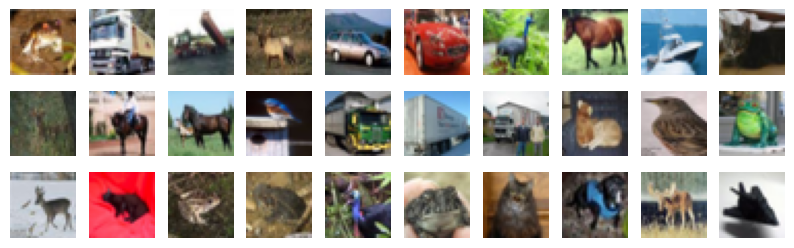

In [4]:
# Visualizamos las primeras 30 imágenes del dataset.
plot_results(X_train[0:30], 10, False)

In [5]:

# Normalización
X_train = X_train.astype(np.float32)

In [6]:
# Reescalado de las imágenes 
X_train = (X_train -127.5) / 127.5

In [7]:
BATCH_SIZE = 128 # Tamaño del batch para el entrenamiento

In [8]:
# Creamos un dataset de TensorFlow a partir de las imágenes de entrenamiento, lo barajamos y lo dividimos en batches.
dataset = tf.data.Dataset.from_tensor_slices(X_train)
dataset = dataset.shuffle(1000)
dataset = dataset.batch(BATCH_SIZE, drop_remainder=True).prefetch(1)

I0000 00:00:1772548027.698128   73614 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6096 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [9]:
# Visualizamos una imagen del dataset para comprobar que se ha cargado correctamente.
X_train[1]

array([[[ 0.20784314,  0.3882353 ,  0.46666667],
        [-0.01176471,  0.07450981,  0.06666667],
        [-0.1764706 , -0.18431373, -0.25490198],
        ...,
        [-0.28627452, -0.25490198, -0.44313726],
        [-0.31764707, -0.29411766, -0.44313726],
        [-0.38039216, -0.3647059 , -0.4509804 ]],

       [[ 0.09803922,  0.25490198,  0.3254902 ],
        [ 0.13725491,  0.2       ,  0.20784314],
        [-0.01960784, -0.01960784, -0.07450981],
        ...,
        [-0.24705882, -0.22352941, -0.3882353 ],
        [-0.39607844, -0.37254903, -0.5137255 ],
        [-0.44313726, -0.42745098, -0.52156866]],

       [[ 0.09803922,  0.21568628,  0.28627452],
        [ 0.09019608,  0.14509805,  0.16862746],
        [-0.09803922, -0.09803922, -0.12156863],
        ...,
        [-0.38039216, -0.35686275, -0.49803922],
        [-0.46666667, -0.4509804 , -0.5686275 ],
        [-0.4745098 , -0.45882353, -0.5686275 ]],

       ...,

       [[ 0.37254903,  0.30980393,  0.3019608 ],
        [ 0

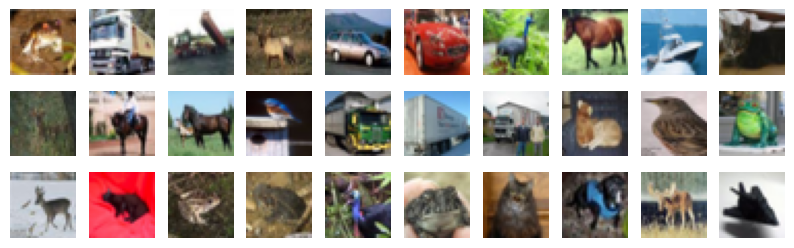

In [10]:
# Visualizamos las primeras 30 imágenes del dataset después de la normalización y el reescalado.
plot_results(X_train[0:30], 10)

### 4. Diseño e implementación de la arquitectura de la red GAN.   

#### 4.1 Arquitectura del Generador

In [11]:
# Creamos el modelo del generador, que toma un vector de ruido como entrada y genera una imagen de 32x32x3 como salida.
noise_input = 100 # Dimensión del vector de ruido que se utilizará como entrada para el generador
generator = keras.models.Sequential([
    keras.layers.Dense(4 * 4 * 128, input_shape=[noise_input], 
                       activation=keras.layers.LeakyReLU(alpha=0.2)),
    keras.layers.Reshape([4, 4, 128]),
    keras.layers.BatchNormalization(),

    #First UpSample doubling the size to 8x8
    keras.layers.Conv2DTranspose(128, kernel_size=4, strides=2, padding="SAME", 
                                 activation=keras.layers.LeakyReLU(alpha=0.2)),
    keras.layers.BatchNormalization(),

    #Second UpSample doubling the size to 16x16
    keras.layers.Conv2DTranspose(128, kernel_size=4, strides=2, padding="SAME", 
                                 activation=keras.layers.LeakyReLU(alpha=0.2)),
    keras.layers.BatchNormalization(),

    #Last UpSample doubling the size to 32x32
    keras.layers.Conv2DTranspose(3, kernel_size=4, strides=2, padding="SAME",
                                 activation='tanh'),
                                 ])

/home/jordi/Documentos/Ribera/Curso_25_26/CEIABD/CEIABD_25_26/.venv/lib/python3.12/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
/home/jordi/Documentos/Ribera/Curso_25_26/CEIABD/CEIABD_25_26/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
generator.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 2048)           │       206,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 128)      │       262,272 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 128)    │       262,272 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 3)      │         6,147 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 739,075 (2.82 MB)

 Trainable params: 738,307 (2.82 MB)

 Non-trainable params: 768 (3.00 KB)

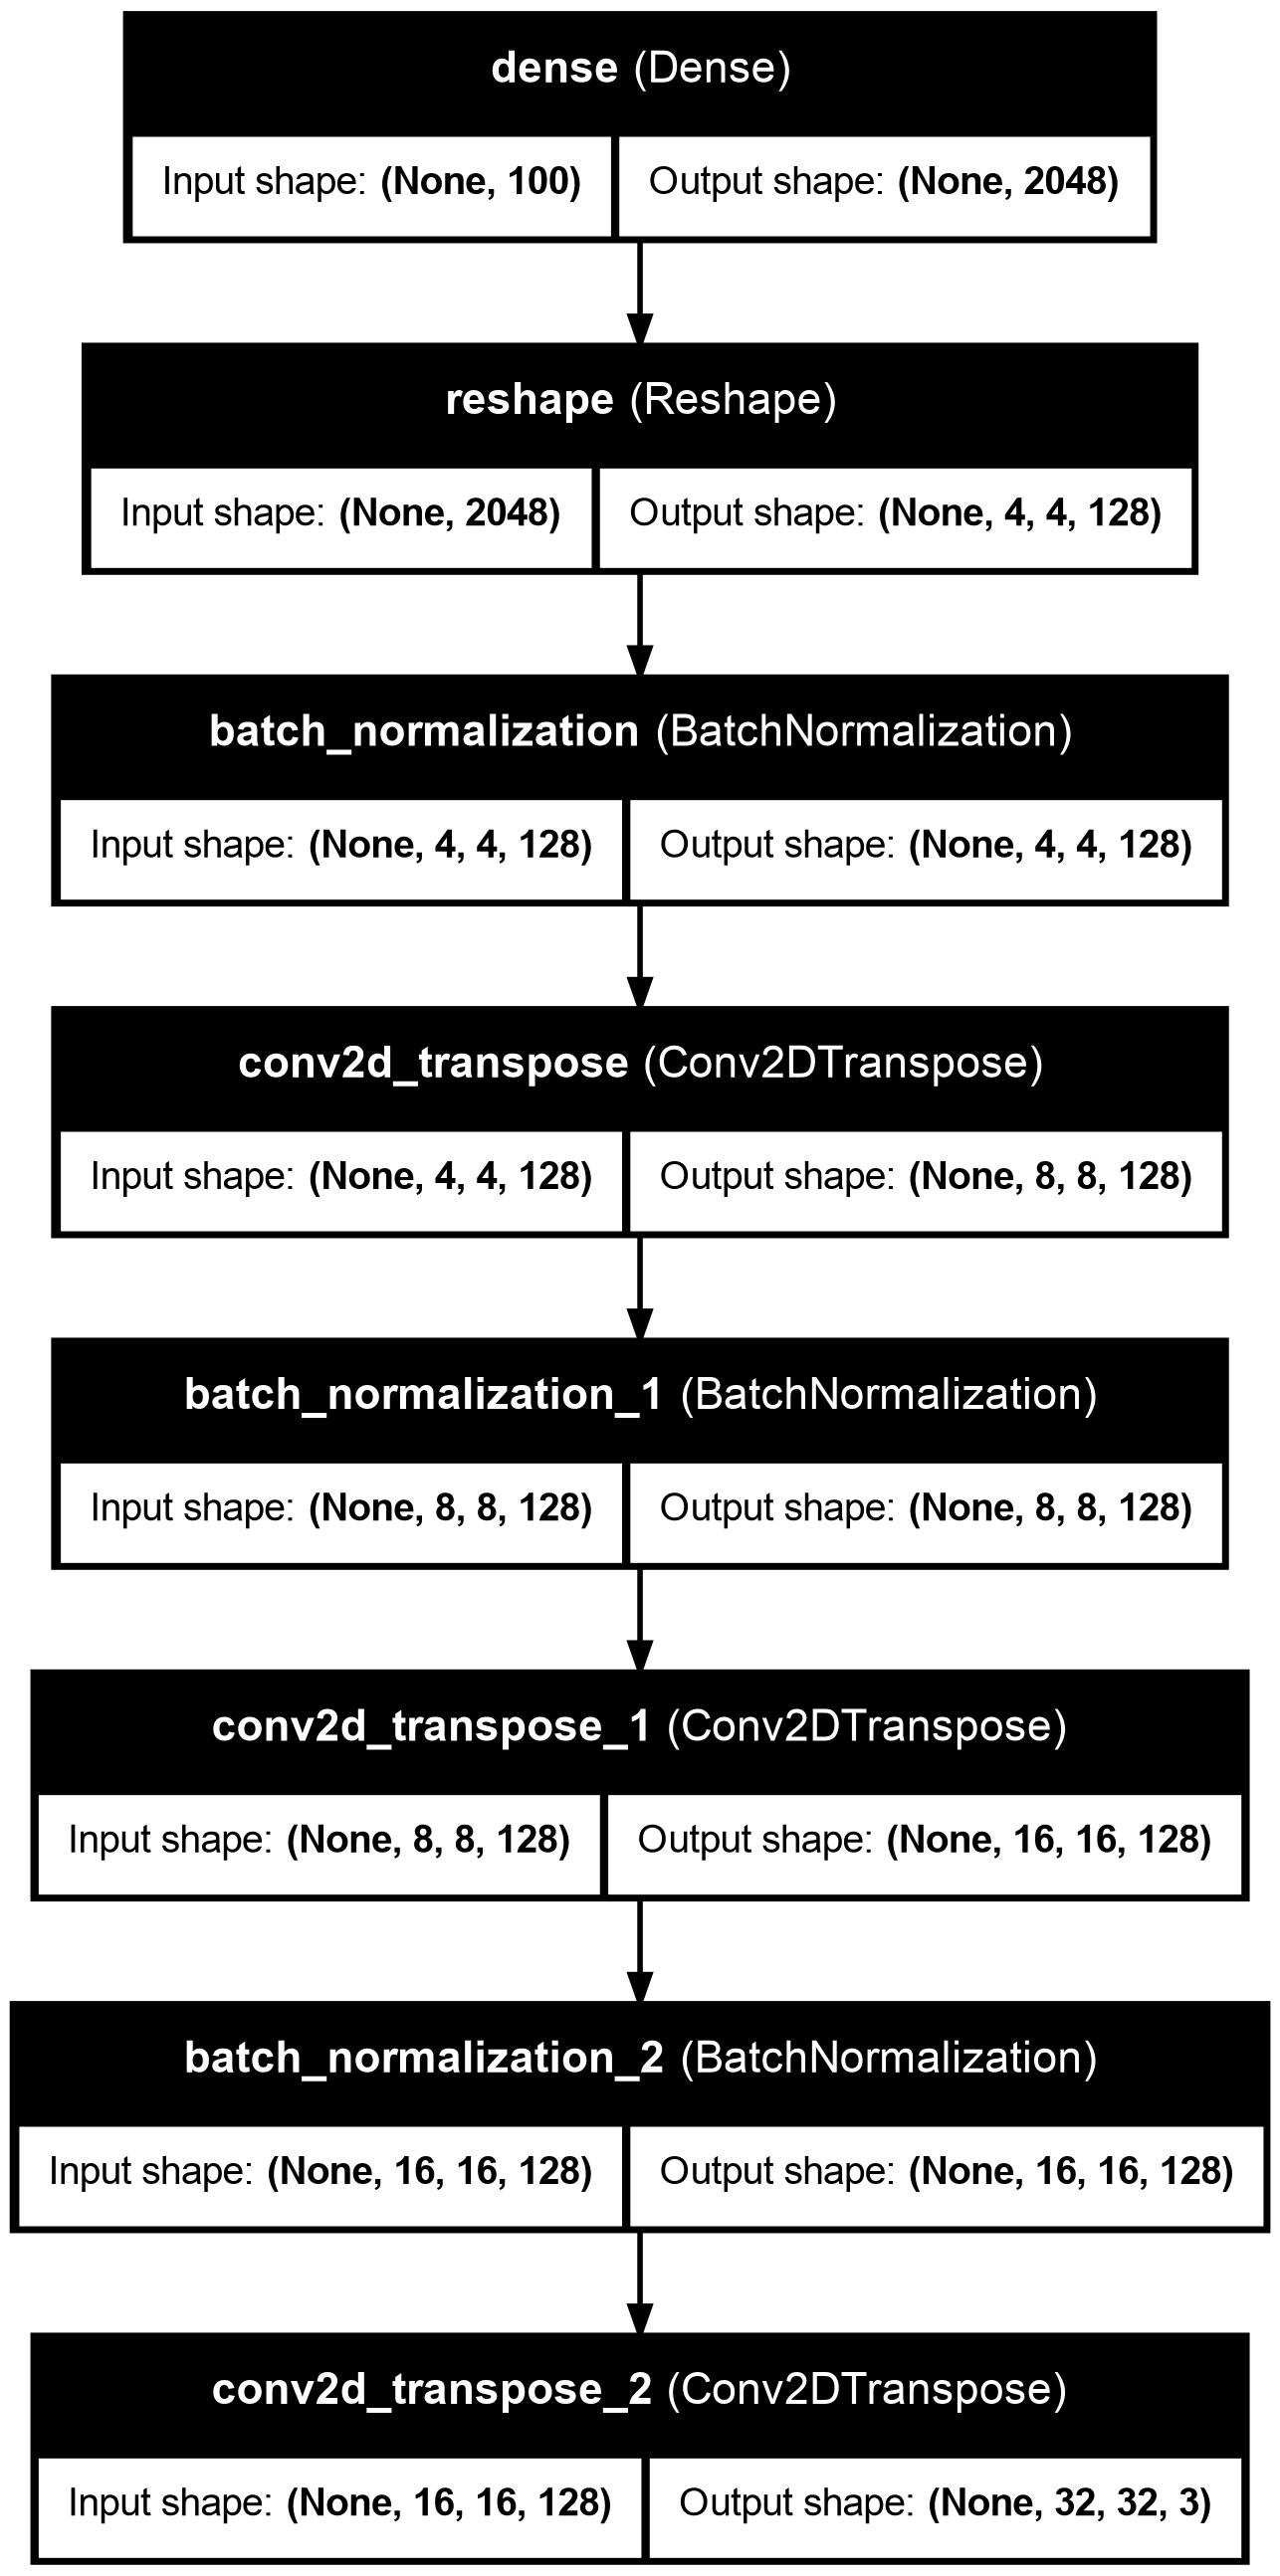

In [13]:

plot_model(generator, show_shapes=True, 
           show_layer_names=True)

In [14]:
# Generación de un batch de ruido de entrada (tamaño del batch = 16)
test_noise = tf.random.normal([16, noise_input])

In [15]:
# Alimentamos el batch de ruido al generador sin entrenar para generar un batch de imágenes falsas.
test_image = generator(test_noise)

2026-03-03 15:27:38.788656: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002


shape of the generated batch: (16, 32, 32, 3)


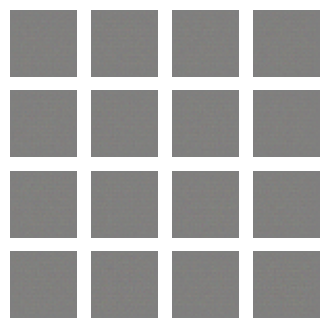

In [16]:
# Visualizamos las imágenes generadas por el modelo sin entrenar.
plot_results(test_image, n_cols=4)

print(f'shape of the generated batch: {test_image.shape}')

#### 4.2 Arquitectura del Discriminador

In [17]:
# Creamos el modelo del discriminador, que toma una imagen de 32x32x3 como entrada y 
# devuelve una probabilidad de que la imagen sea real o falsa.

discriminator = keras.models.Sequential([
    keras.layers.Conv2D(64, kernel_size=5, strides=2, padding="SAME",
                        activation=keras.layers.LeakyReLU(0.2),
                        input_shape=[32, 32, 3]),
    keras.layers.Dropout(0.4),

    keras.layers.Conv2D(64, kernel_size=3, strides=2, padding="SAME",
                        activation=keras.layers.LeakyReLU(0.2)),
    keras.layers.Dropout(0.4),

    keras.layers.Conv2D(64, kernel_size=3, strides=2, padding="SAME",
                        activation=keras.layers.LeakyReLU(0.2)),
    keras.layers.Dropout(0.4),
    
    keras.layers.Flatten(),
    keras.layers.Dense(1, activation="sigmoid")
])

/home/jordi/Documentos/Ribera/Curso_25_26/CEIABD/CEIABD_25_26/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


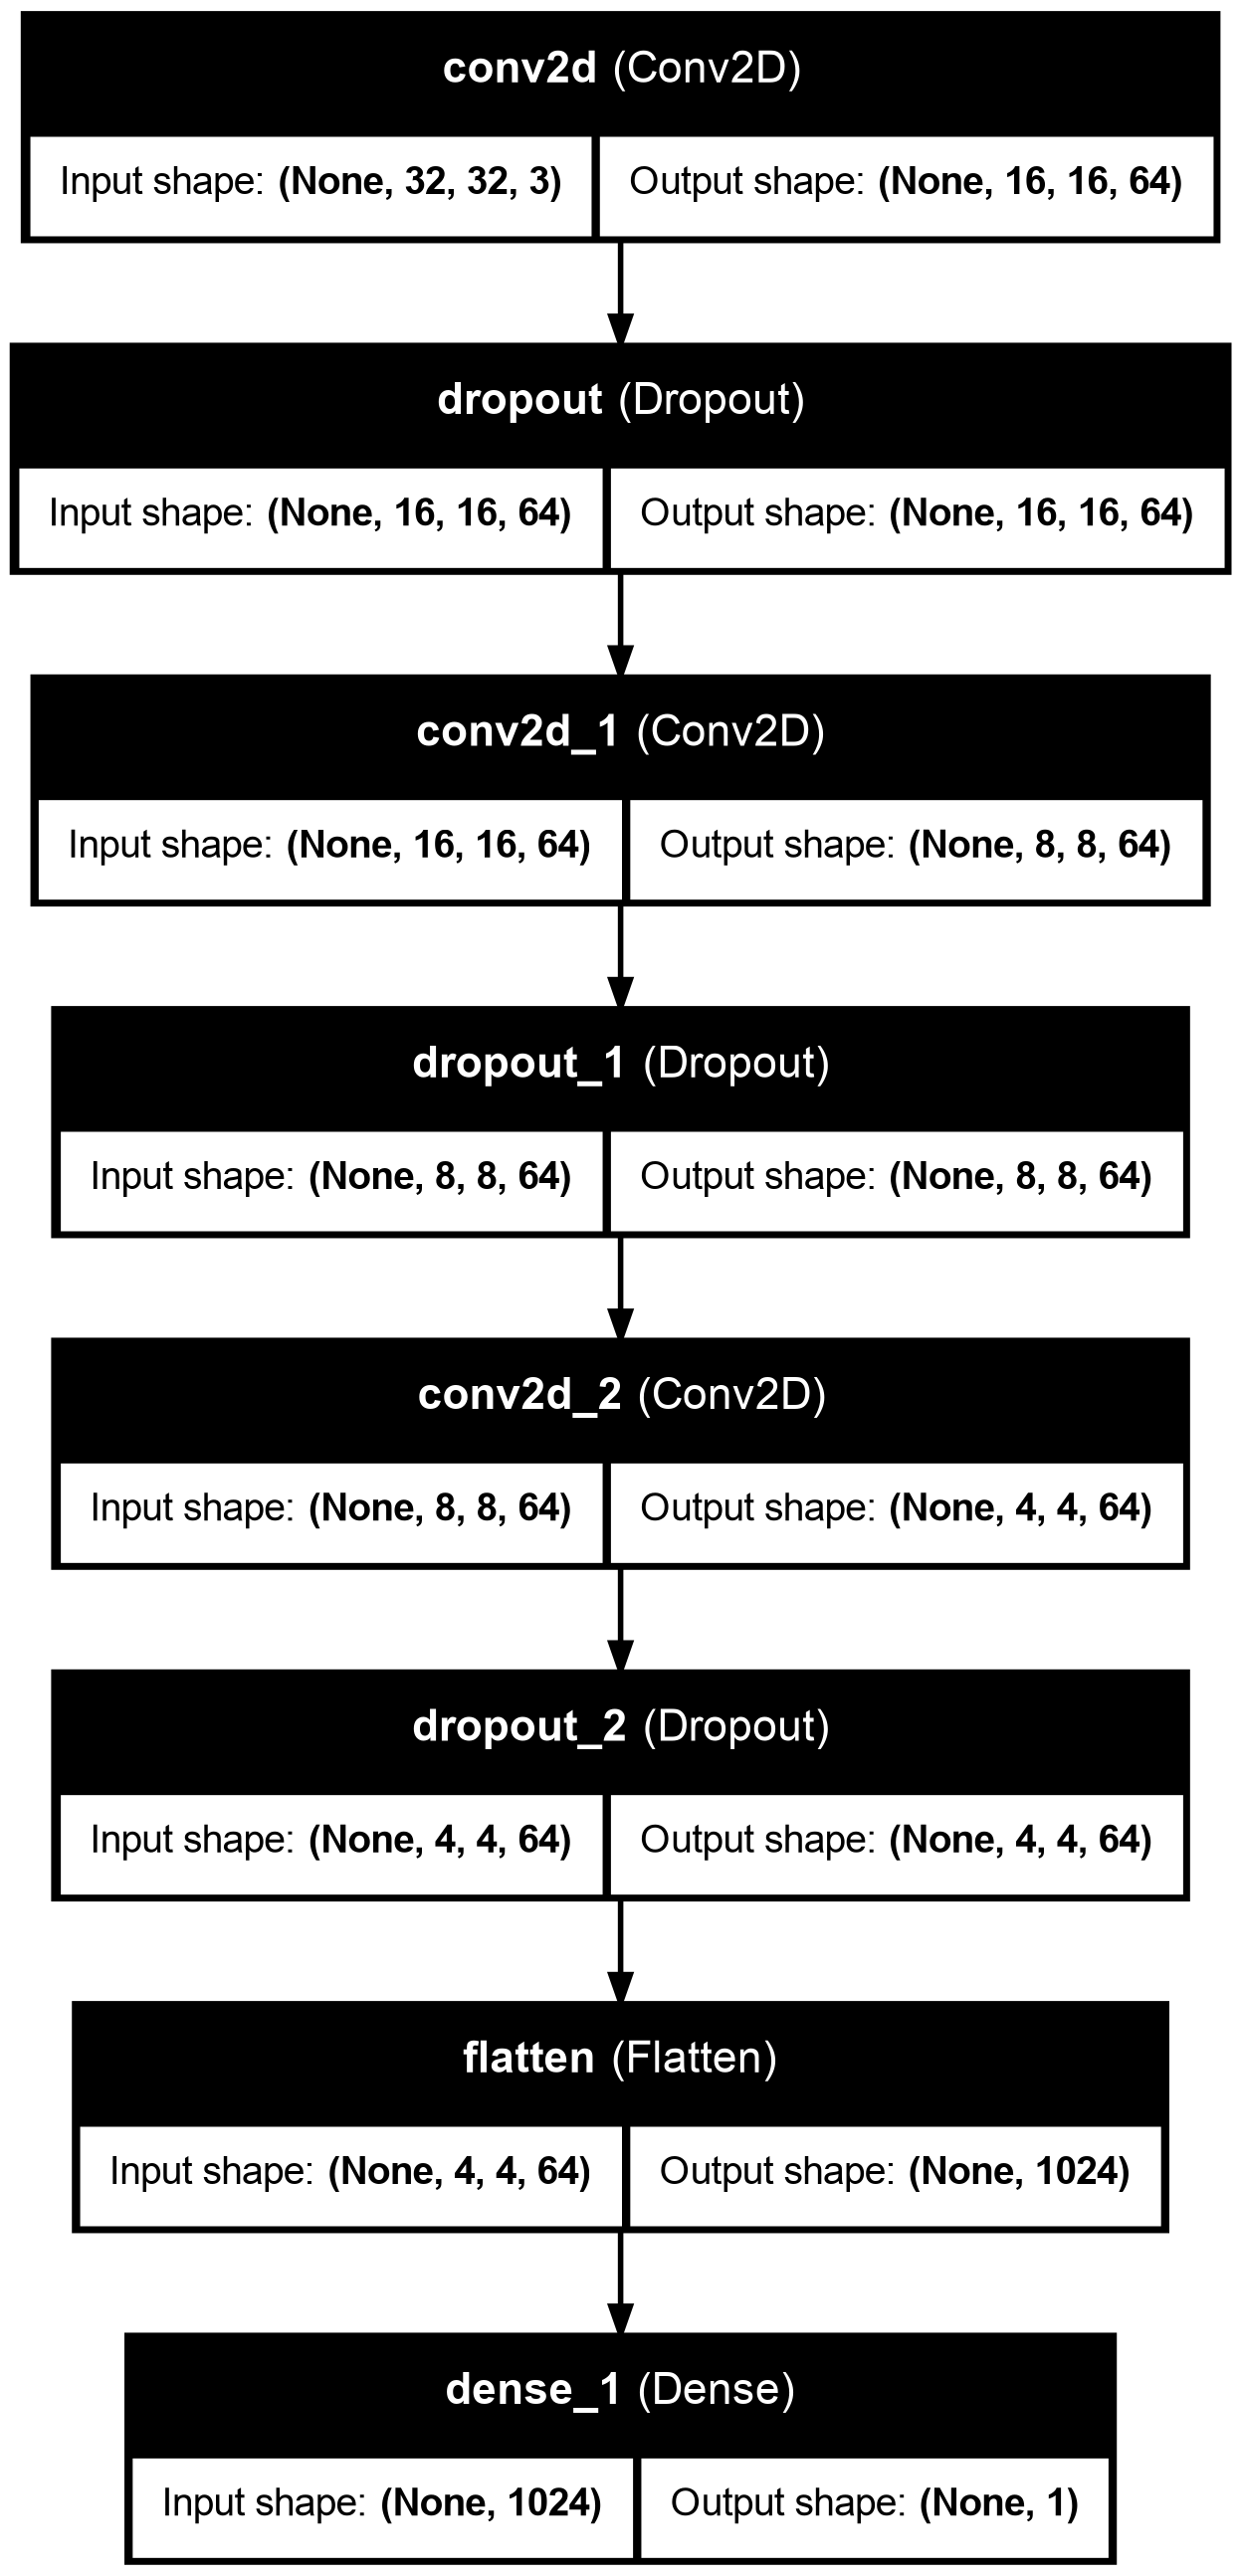

In [18]:
plot_model(discriminator, show_shapes=True, 
           show_layer_names=True)

#### 4.3 Ensamblado de la red GAN: Generador + Discriminador

In [19]:
# Creamos el modelo de la GAN combinando el generador y el discriminador.
# El generador se conecta al discriminador, de modo que el modelo completo 
# toma un vector de ruido como entrada y devuelve la probabilidad de que la imagen generada sea real o falsa.

gan = keras.models.Sequential([generator, discriminator])

In [20]:
# Compilamos el modelo del discriminador con la función de pérdida de entropía cruzada binaria y el optimizador RMSprop.

#discriminator.compile(loss="binary_crossentropy", optimizer="rmsprop") 

optimizer_disc = keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
optimizer_gen = keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
discriminator.compile(loss='binary_crossentropy', optimizer=optimizer_disc, metrics=['accuracy'])

discriminator.trainable = False
gan.compile(loss="binary_crossentropy", optimizer=optimizer_gen)

In [21]:

gan.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 32, 32, 3)      │       739,075 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 1)              │        79,745 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 818,820 (3.12 MB)

 Trainable params: 738,307 (2.82 MB)

 Non-trainable params: 80,513 (314.50 KB)

### 5. Preprocesado del dataset para acomodarlo a la red GAN

In [22]:
# Funciones para suavizar las etiquetas de las imágenes reales y falsas, lo que ayuda a estabilizar el entrenamiento de la GAN.

def smooth_positive(y):
  return y -0.2 + (np.random.random(y.shape) * 0.4)

def smooth_negative(y):
  return y + np.random.random(y.shape) * 0.3

### 6. Funciones de utilidades y entrenamiento de la red GAN

In [23]:
# Función para generar un batch de muestras reales a partir del dataset.

def generate_real_samples(dataset, n_samples):
  i = np.randint(0, dataset.shape[0], n_samples)
  X = dataset[i]
  y


In [ ]:
# Función para entrenar la GAN, que define el bucle de entrenamiento en dos fases: 
# primero se entrena el discriminador con imágenes reales y falsas, y 
# luego se entrena el generador para engañar al discriminador.

def train_gan(gan, dataset, random_normal_dimensions, n_epochs=30):
    """ Defines the two-phase training loop of the GAN
    Args:
      gan -- the GAN model which has the generator and discriminator
      dataset -- the training set of real images
      random_normal_dimensions -- dimensionality of the input to the generator
      n_epochs -- number of epochs
    """
    generator, discriminator = gan.layers
    for epoch in range(n_epochs):
        print("Epoch {}/{}".format(epoch + 1, n_epochs))       
        for real_images in dataset:
            
            # Inferimos el tamaño del batch a partir del batch de entrenamiento actual, 
            # lo que nos permite manejar batches de diferentes tamaños durante el entrenamiento.
            batch_size = real_images.shape[0]

            # Entrenamiento del discriminador - FASE 1
            # Generación del ruido de entrada para el generador
            noise = tf.random.normal(shape=[batch_size, random_normal_dimensions])

            # Usamos el ruido para generar imágenes falsas
            fake_images = generator(noise)

            # Esta concatenación de imágenes reales y falsas se utiliza para entrenar el discriminador, 
            # que aprende a distinguir entre ambas.
            mixed_images = tf.concat([fake_images, real_images], axis=0)

            # Crea los labels para el discriminador
            # 0 para las imágenes falsas
            # 1 para las imágenes reales
            discriminator_zeros = smooth_negative(np.zeros((batch_size, 1)))
            discriminator_ones = smooth_positive(np.ones((batch_size, 1)))
            discriminator_labels= tf.convert_to_tensor(np.concatenate((discriminator_zeros, discriminator_ones)))
            #discriminator_labels = tf.constant([[0.]] * batch_size + [[1.]] * batch_size)

            # Aseguramos que el discriminador sea entrenable 
            # para que pueda actualizar sus pesos durante esta fase de entrenamiento.
            discriminator.trainable = True

            # usamos train_on_batch para entrenar el discriminador con las imágenes mixtas y las etiquetas del discriminador
            discriminator.train_on_batch(mixed_images, discriminator_labels)

            # Entrenamiento del generador - FASE 2
            # creación de un batch de ruido de entrada para alimentar a la GAN
            noise = tf.random.normal(shape=[batch_size, random_normal_dimensions])
            
            # etiquetado de todas las imágenes generadas como "reales" 
            # para entrenar el generador a engañar al discriminador.
            generator_ones = smooth_positive(np.ones((batch_size, 1)))
            generator_labels = tf.convert_to_tensor(generator_ones)
            #generator_labels = tf.constant([[1.]] * batch_size)

            # congelación del discriminador para que no se actualicen sus pesos durante el entrenamiento del generador.
            discriminator.trainable = False

            # entrenamos la GAN con el ruido de entrada y las etiquetas del generador todo ello establecido como verdadero, 
            # lo que actualiza los pesos del generador para intentar engañar al discriminador.
            gan.train_on_batch(noise, generator_labels)
        
        # graficamos las imágenes falsas utilizadas para entrenar el discriminador al final
        # de cada época para visualizar el progreso del entrenamiento.
        plot_results(fake_images[0:30], 10)                     
        plt.show()  

In [25]:

# Ejemplo de etiquetas suavizadas para el entrenamiento del discriminador y el generador.
batch_size=5

#discriminator_zeros = np.zeros((batch_size, 1)) #+ np.ones(batch_size)
discriminator_zeros = smooth_negative(np.zeros((batch_size, 1)))
discriminator_ones = smooth_positive(np.ones((batch_size, 1)))
discriminator_labels= tf.convert_to_tensor(np.concatenate((discriminator_zeros, discriminator_ones)))

In [26]:
# Visualizamos las etiquetas suavizadas para el entrenamiento del discriminador.
discriminator_labels

<tf.Tensor: shape=(10, 1), dtype=float64, numpy=
array([[0.14995429],
       [0.1923428 ],
       [0.24884955],
       [0.13898228],
       [0.19924108],
       [0.82964391],
       [1.05454634],
       [1.18205367],
       [1.13840784],
       [1.15419507]])>

In [27]:
# Ahora, volvemos a crear las etiquetas sin suavizar para el entrenamiento del discriminador y el generador.
discriminator_labels = tf.constant([[0]]*batch_size + [[1]]*batch_size)
discriminator_labels

<tf.Tensor: shape=(10, 1), dtype=int32, numpy=
array([[0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1]], dtype=int32)>

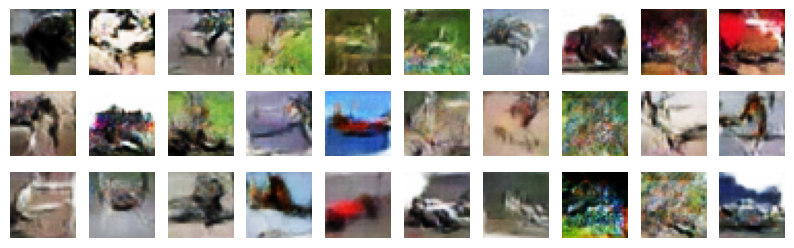

In [28]:
# Lanzamos el entrenamiento de la GAN durante 40 épocas utilizando la función de entrenamiento definida anteriormente.
train_gan(gan, dataset, noise_input, 40)

## Ejercicio.   

Tomar el dataset de celebridades mencionado al principio del notebook y preparar la GAN para la creación de rostros humanos.